# Swarm Data Fusion toolbox demo notebook

**Swarm Data Fusion is a Python tool designed to combine Swarm satellite data with a wide range of ionosphere-thermosphere observations. The goal of SwarmDF is to maximize contextual information around the Swarm satellites for studying local electrodynamics in the high-latitude ionosphere.**


This notebook serves as documentation for the SwarmDF Python module. It guides the reader step by step through a typical SwarmDF run.

Alternatively, users may run swarmDF_GUI.py from a terminal to access a graphical user interface. The GUI is designed to be user-friendly and does not require prior familiarity with the package. It provides the outputs needed for further analysis.

For users who wish to go beyond the GUI, the same analysis can be reproduced by following the steps presented in this notebook.

## Imports

In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from swarm_orbit_and_grid import swarm_trajectory
from data_collect import DataManager
from lompe_analysis import run_lompe, lompe_output
from conductance import compute_conductances
from lompeOSSE_analysis import run_lompeOSSE, lompeOSSE_output


## Input

### Main input

Start by choosing a Swarm satellite and defining the time interval for the study.  
This is the only input required before SwarmDF can run. All additional parameters have default values.

In [2]:
sat_id = 'A'
start = datetime(2014, 12, 15, 1, 12, 0)
end   = datetime(2014, 12, 15, 1, 14, 0)

### Datasets


Choose datasets among SuperDARN, SuperMAG, Iridium/Ampere, Swarm electric field and Swarm magnetic field. By default, all datasets are selected. 

In [3]:
datasets2download = ['superdarn', 'supermag', 'iridium_ampere', 'swarm_mag', "swarm_efield"]

### Grid

Define the extent, spatial resolution, and temporal spacing of the successive 2D regions surrounding the selected Swarm satellite along its trajectory.

In [4]:
L, W = 1000,1000
Lres, Wres = 70, 70

grid_params = L, W, Lres, Wres #TODO make this a dict

time_step = 60 # [s]

### Conductance

! Coductances are a major input for Lompe. 
Define the model of your choice. 

In [5]:
conductance_method = 'Zang & Paxton model'

kp_value = 4
f107_value = 100
background_value = 2 

conductance_params = {"kp": kp_value, "f107": f107_value, "background": background_value}

## Data fusion 

!! 
using sample input datasets
collect swarm data + collect additional data around swarm satellite track within grid + show trajectory and data distribution

The script data_collect.py runs in the background, it checks if the datafiles requested by the user already exist in their data folder, and downloads the files if not. 

SwarmDF will gather Swarm orbit data together with the additional datasets and perform Lompe analyses on those grids, with a default temporal spacing of 30 s between successive grids/analyses.

In [ ]:
######################
# Collect data
######################

# the user has to create their own sample_dataset folder
data_path='/Users/margot/Docs/Academia/Research/Python/SwarmDF/sample_datasets/' # TODO fix that

# Fetch and load data
datahandler = DataManager(start, data_path, datasets2download)
datasets = datahandler.datasets

Fetching data...
Loading data...
Loaded swarm data from disk.
Loaded swarm_mag data from disk.
⚠️  swarm_efield: file loaded but dataset is EMPTY (0 rows)
Loaded superdarn data from disk.
Loaded supermag data from disk.
Loaded iridium_ampere data from disk.


In [3]:
import os 
from pathlib import Path
base_dir = Path(__file__).resolve().parent.parent  # go up one level if this is in a submodule
data_path = os.path.join(base_dir, 'sample_datasets') # path to sample_dataset


NameError: name '__file__' is not defined

In [40]:
datasets['swarm']

,MLT,Latitude,Radius,F,Spacecraft,Longitude,F_MCO_SHA_2D,F_IGRF,QDLat,QDLon,...,B_NEC_MCO_SHA_2D_C,B_NEC_N,B_NEC_E,B_NEC_C,B_NEC_IGRF_N,B_NEC_IGRF_E,B_NEC_IGRF_C,B_n,B_e,B_u
Timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-15 00:00:00,15.307294,26.147953,6835831.60,33871.6407,A,-122.220974,33876.015262,33876.851443,31.439939,-54.797306,...,26210.032453,21073.8774,4028.7373,26209.2949,21080.515519,4021.810144,26212.172216,-6.638119,6.927156,2.877316
2014-12-15 00:00:00,15.412182,25.665464,6835916.06,0.0000,C,-120.791327,33823.121815,33824.395313,31.201914,-53.223995,...,26083.283130,21158.7969,3949.0443,26083.8070,21167.900932,3940.940712,26085.986175,-9.104032,8.103588,2.179175
2014-12-15 00:00:00,16.613516,30.891504,6886573.76,37106.1835,B,-103.723153,37100.400343,37097.497717,39.474663,-35.203972,...,31847.165917,18895.9945,2182.7065,31859.6978,18905.381545,2172.726737,31844.782053,-9.387045,9.979763,-14.915747
2014-12-15 00:00:10,15.318048,25.508602,6835946.98,33580.8184,A,-122.226256,33585.592973,33586.648697,30.793816,-54.677898,...,25719.650196,21214.9360,4015.5305,25718.7185,21221.804735,4009.575393,25721.999916,-6.868735,5.955107,3.281416
2014-12-15 00:00:10,15.422656,25.026116,6836031.50,0.0000,C,-120.796904,33531.123298,33532.628879,30.554012,-53.108776,...,25588.463612,21299.9464,3936.5906,25588.6184,21309.056932,3929.823743,25591.361385,-9.110532,6.766857,2.742985
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-15 23:59:40,21.897301,-82.173324,6845219.09,40989.9651,A,38.132717,41008.384121,41007.640363,-73.628510,44.267799,...,-38740.529886,6908.1504,-11642.4217,-38689.4255,6823.819537,-11587.175842,-38740.152440,84.330863,-55.245858,-50.726940
2014-12-15 23:59:40,17.270971,-30.702507,6895117.90,24952.1853,B,-102.240585,24972.079219,24971.249389,-21.379345,-25.127129,...,-15423.207416,18899.3340,5222.8793,-15431.9431,18934.783926,5216.370847,-15421.631849,-35.449926,6.508453,10.311251
2014-12-15 23:59:50,17.283340,-31.333395,6895166.96,25114.2651,B,-102.248663,25133.529613,25132.879877,-21.967407,-24.983459,...,-15792.967468,18788.1475,5295.8607,-15801.3388,18823.232097,5289.445667,-15791.432768,-35.084597,6.415033,9.906032


In [39]:
smag = datasets['supermag']
smag.lat.max()

79.300003

Plot the local grid along the Swarm trajectory as well as the selected data.
A gif is created in the user's folder. 

The swarm_orbit_and_grid.py script ... 

In [7]:
# Animation speed
gif_speed= 550 # [ms]
# TODO make these parameters default values in swarm_traj and lompe and lompeosse

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


hemisphere: north
Generating SwarmA trajectory animation for each time step...


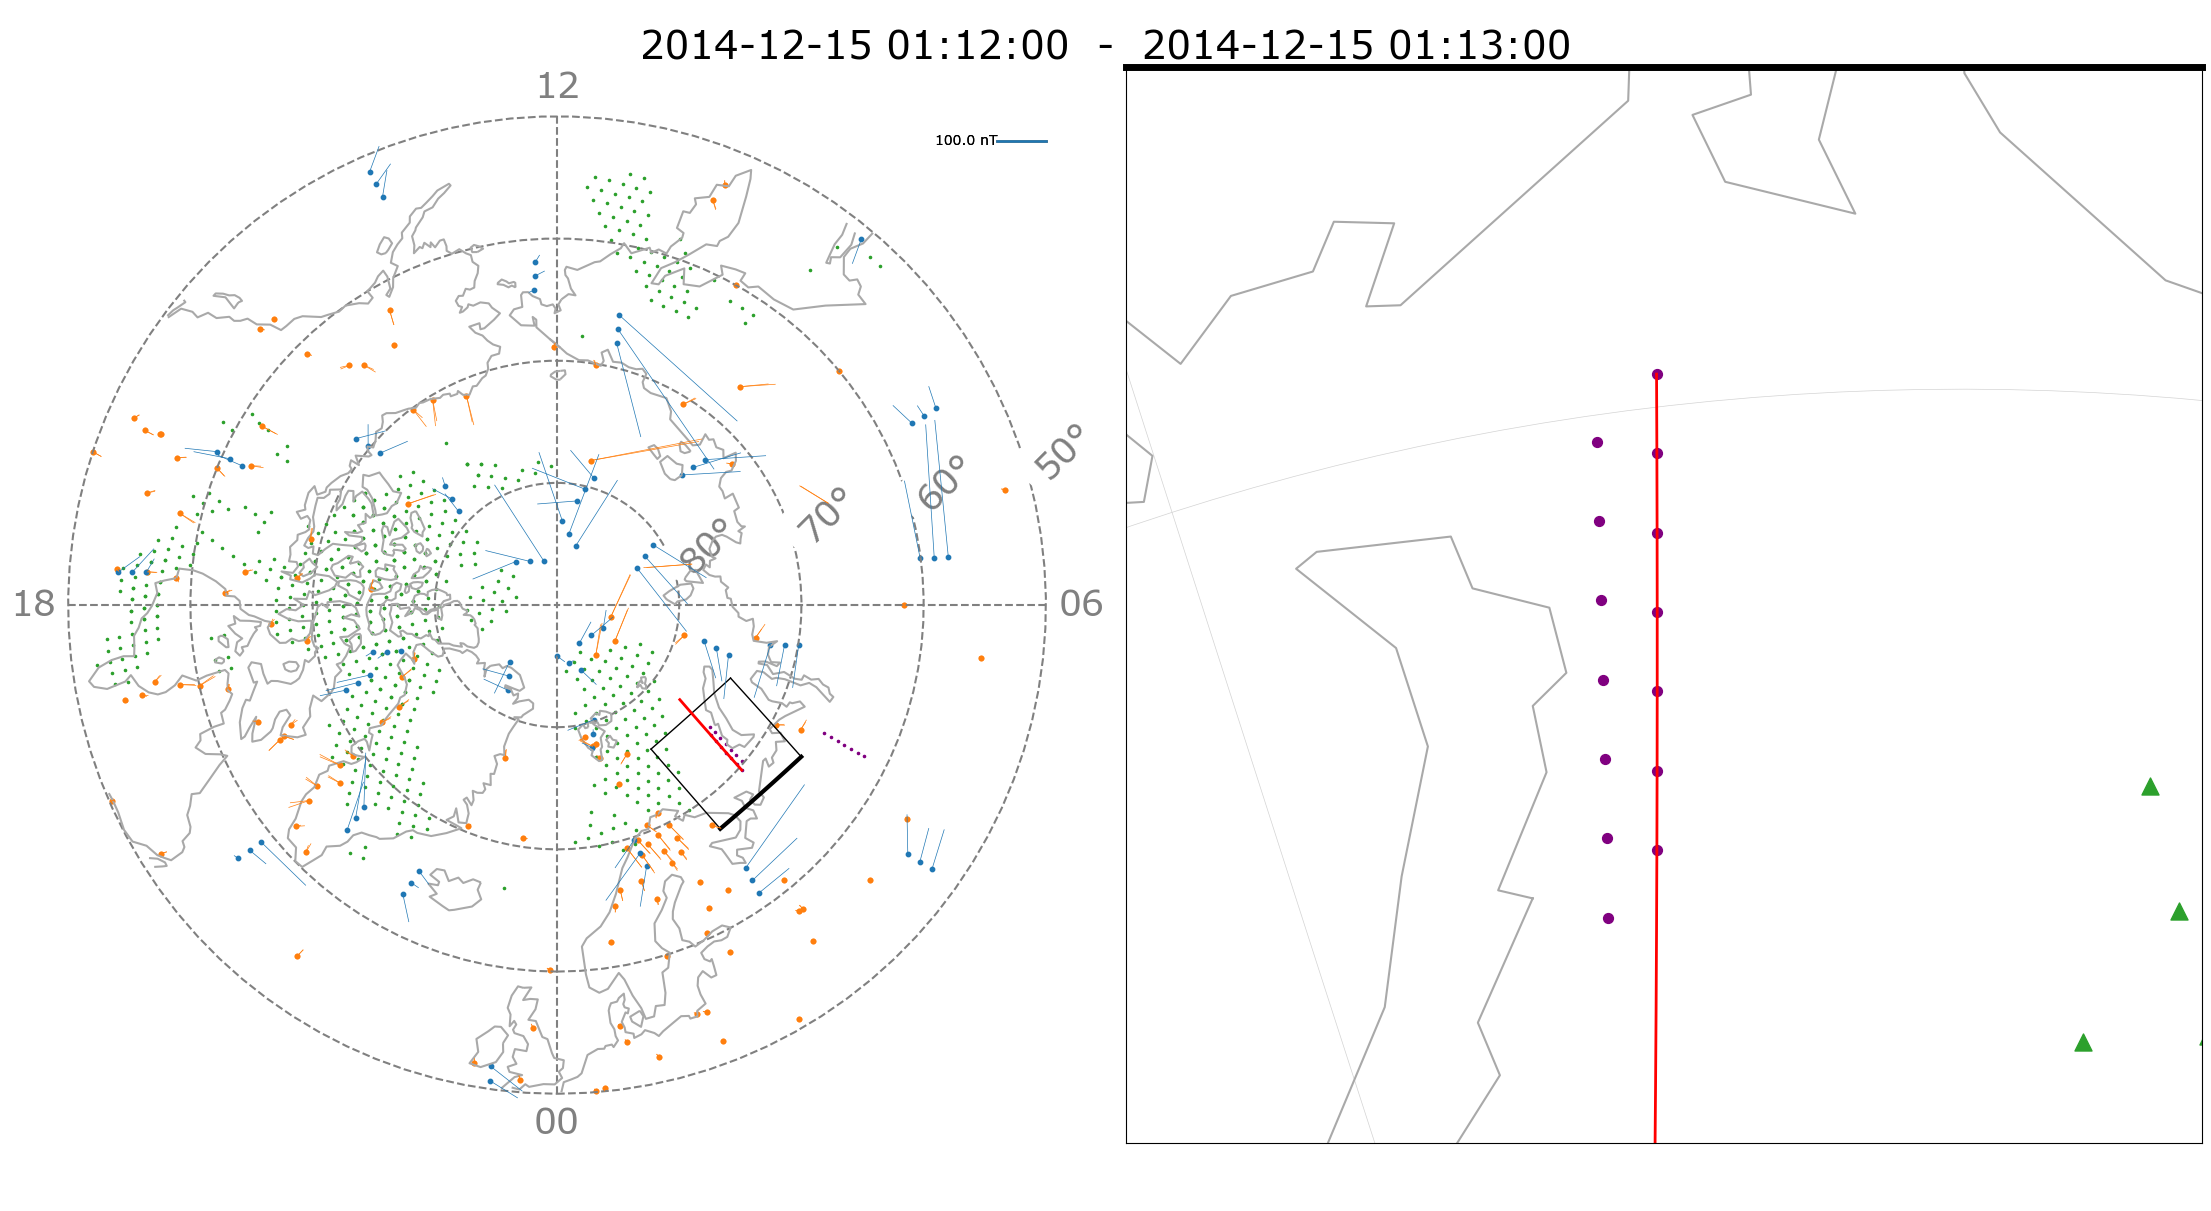

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


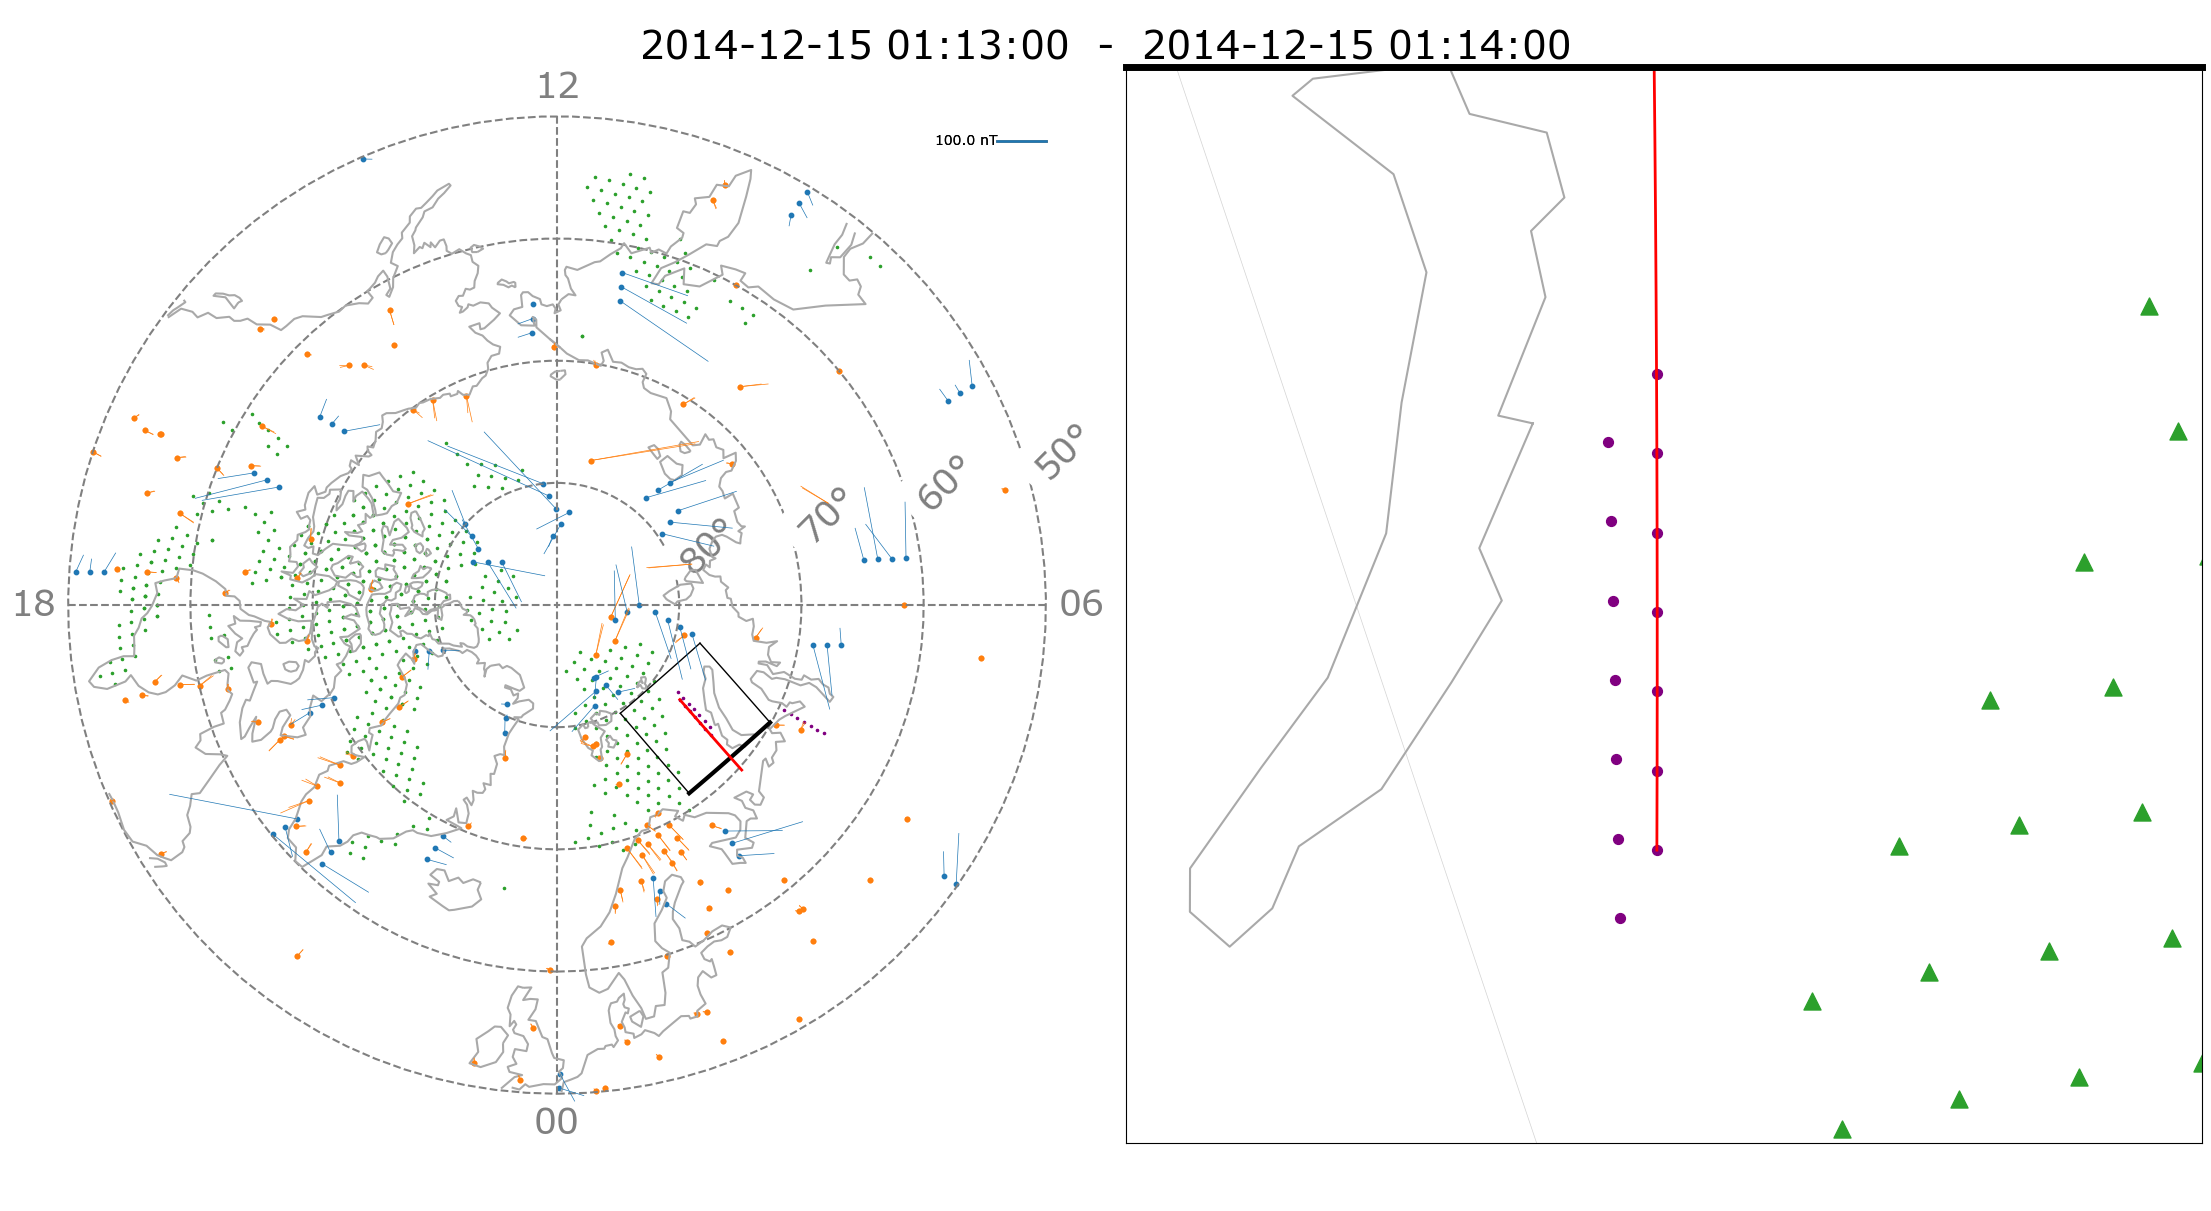

Figures with Swarm trajectory, grid, and data distribution for each time step saved in: outputs/tmp/
GIF saved in outputs directory: outputs/swarmA_and_data.gif


In [8]:
data_frames, grids = swarm_trajectory(sat_id, start, end, time_step, grid_params, datasets, gif_speed, show_data=True)

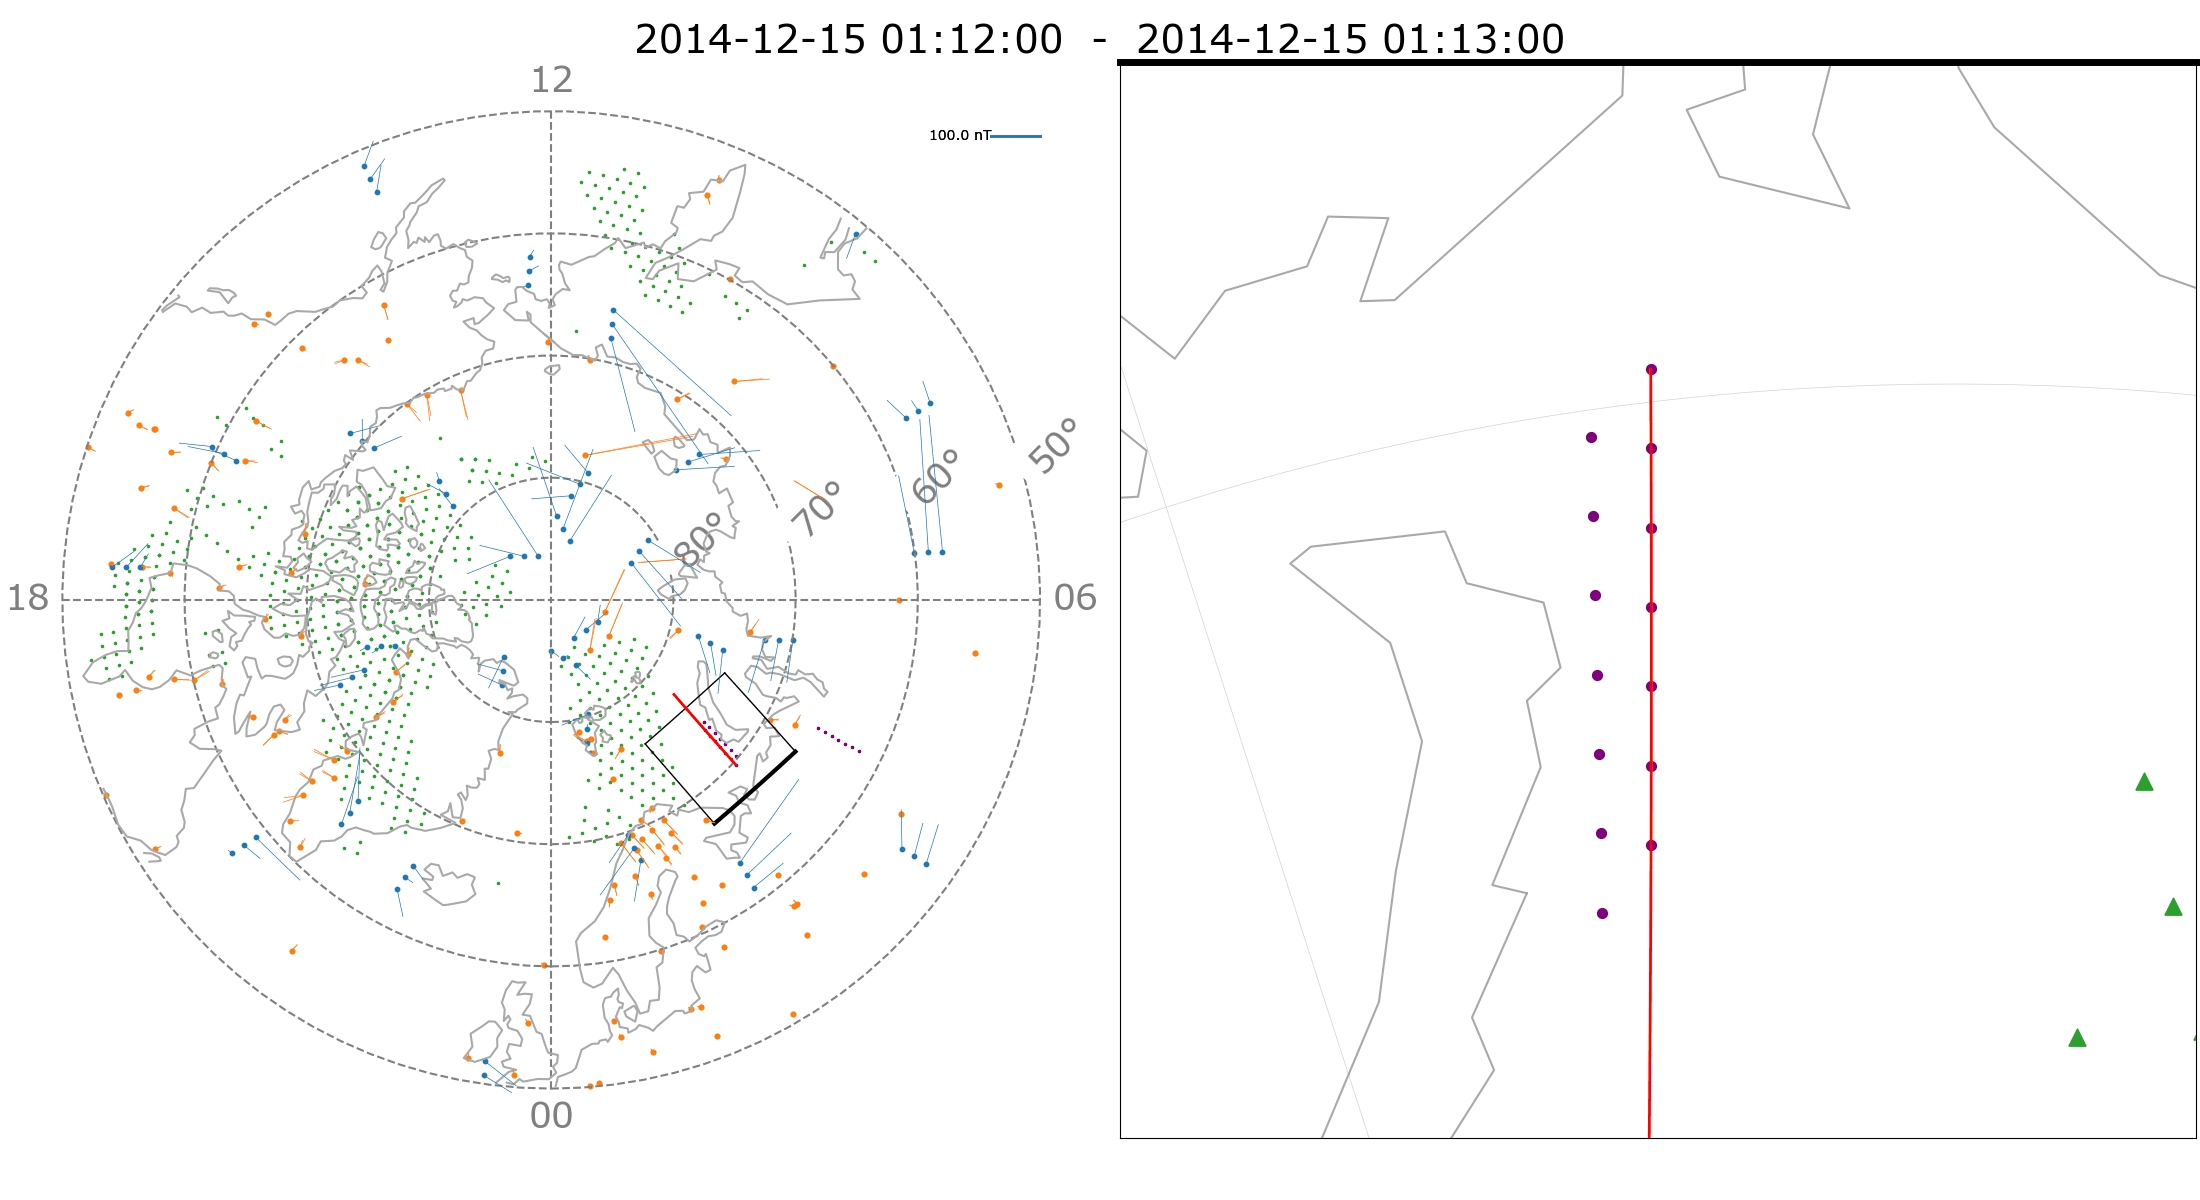

In [9]:
data_frames[0].save(
    "trajectory.gif",
    save_all=True,
    append_images=data_frames[1:],
    duration=750,
    loop=0
)

from IPython.display import Image, display

display(Image(filename='trajectory.gif')) #TODO compare with the gif saved in outputs

## Run Lompe analysis

Define conductance

In [10]:
SHs, SPs = compute_conductances(conductance_method, start, end, time_step, grids, conductance_params)

Conductance method: Zang & Paxton model


Create Lompe Emodel, run inversion and plot reconstructed electrodynamics

Running Lompe analysis...
swarm dataset, fix that later
! need to fix Swarm functions in prepare_data
swarm dataset, fix that later
! need to fix Swarm functions in prepare_data


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


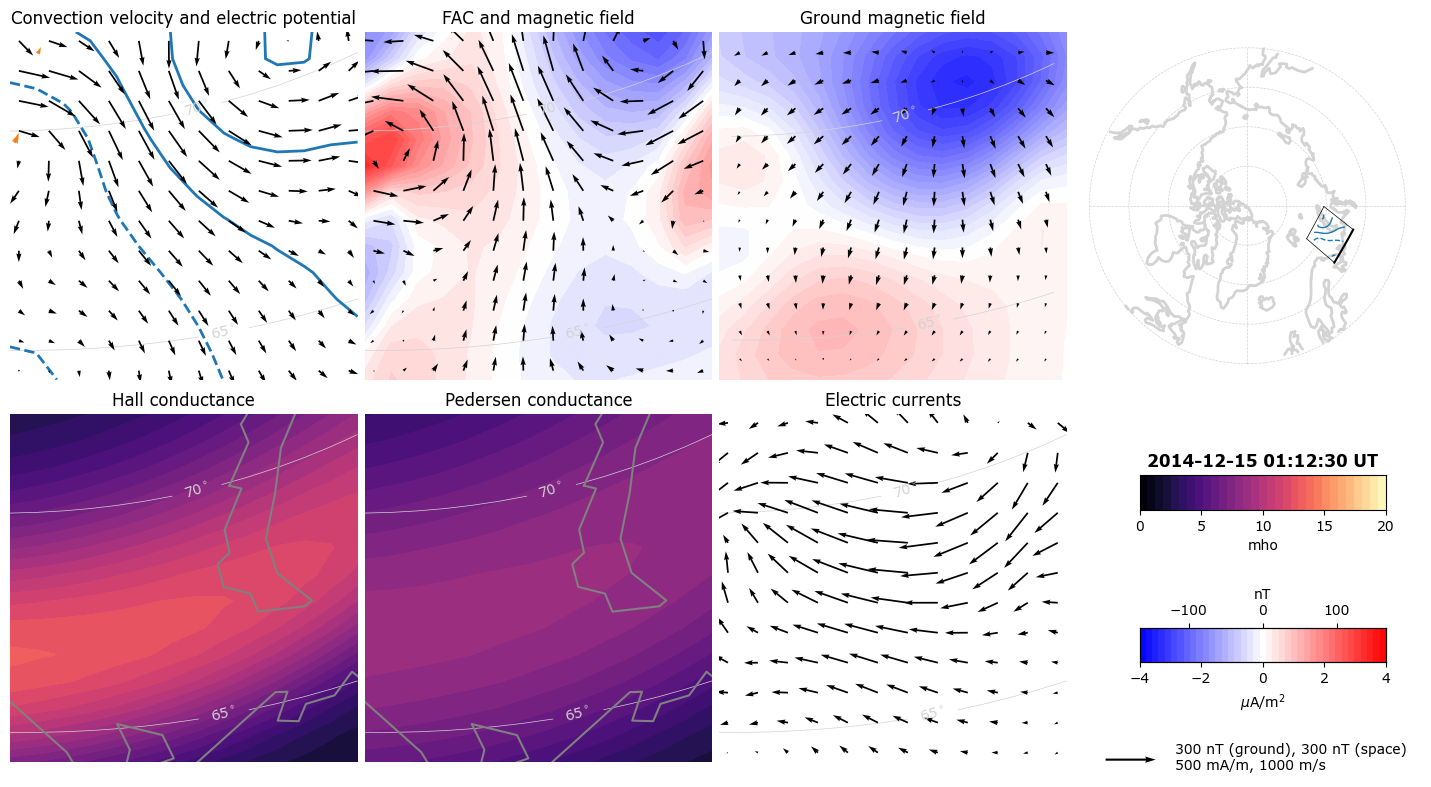

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


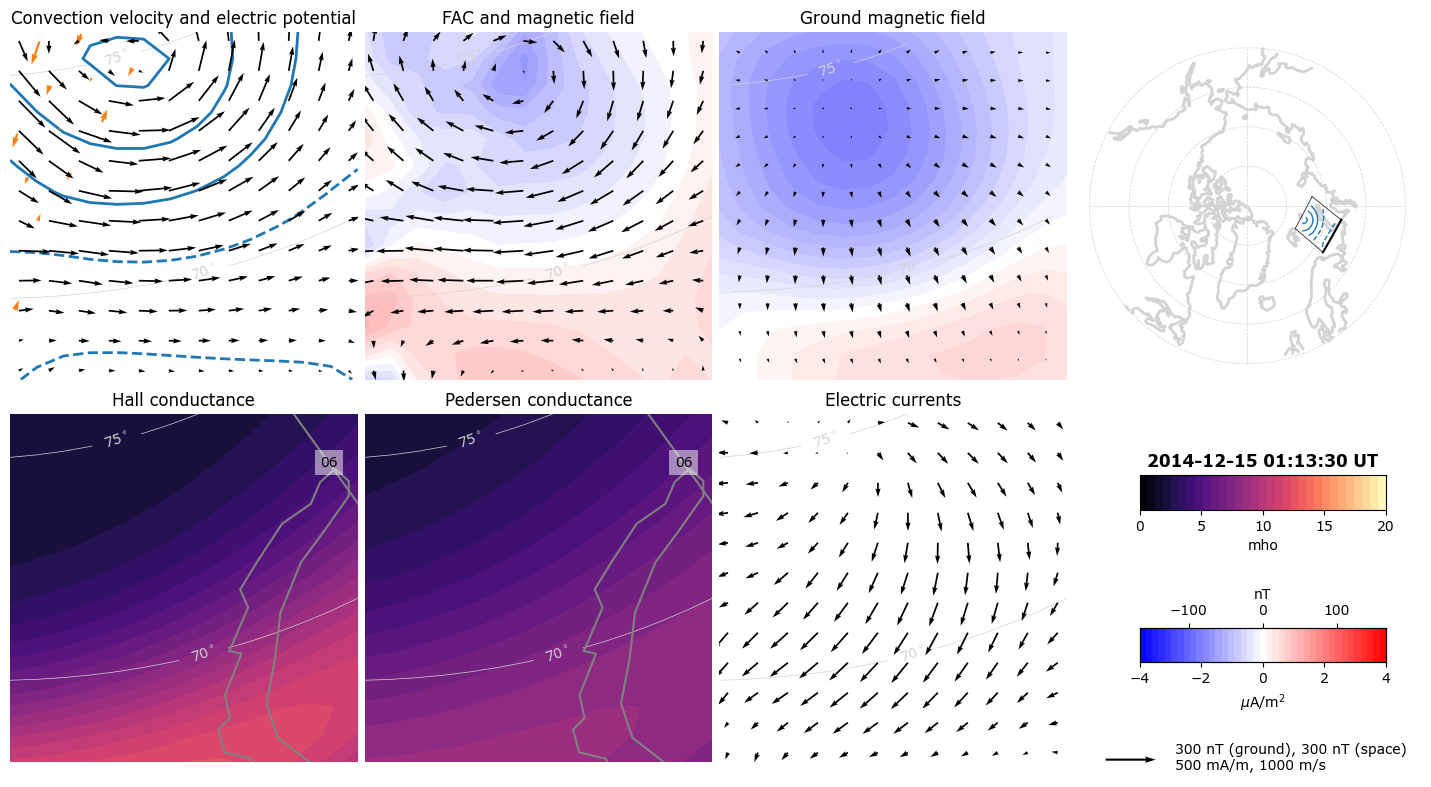

Lompe output figures for each time step saved in temporary folder: outputs/tmp/
GIF saved in outputs directory: outputs/lompe_l1-1_l2-1.gif


In [11]:
# Regularization parameters for Lompe analysis
l1, l2 = 1, 1

lompe_models = run_lompe(grids, start, end, time_step, datasets, SHs, SPs, l1, l2)
lompe_frames = lompe_output(lompe_models, gif_speed)

In [30]:
lompe_models[0]['model'].data['convection'][0].values.shape

(3,)

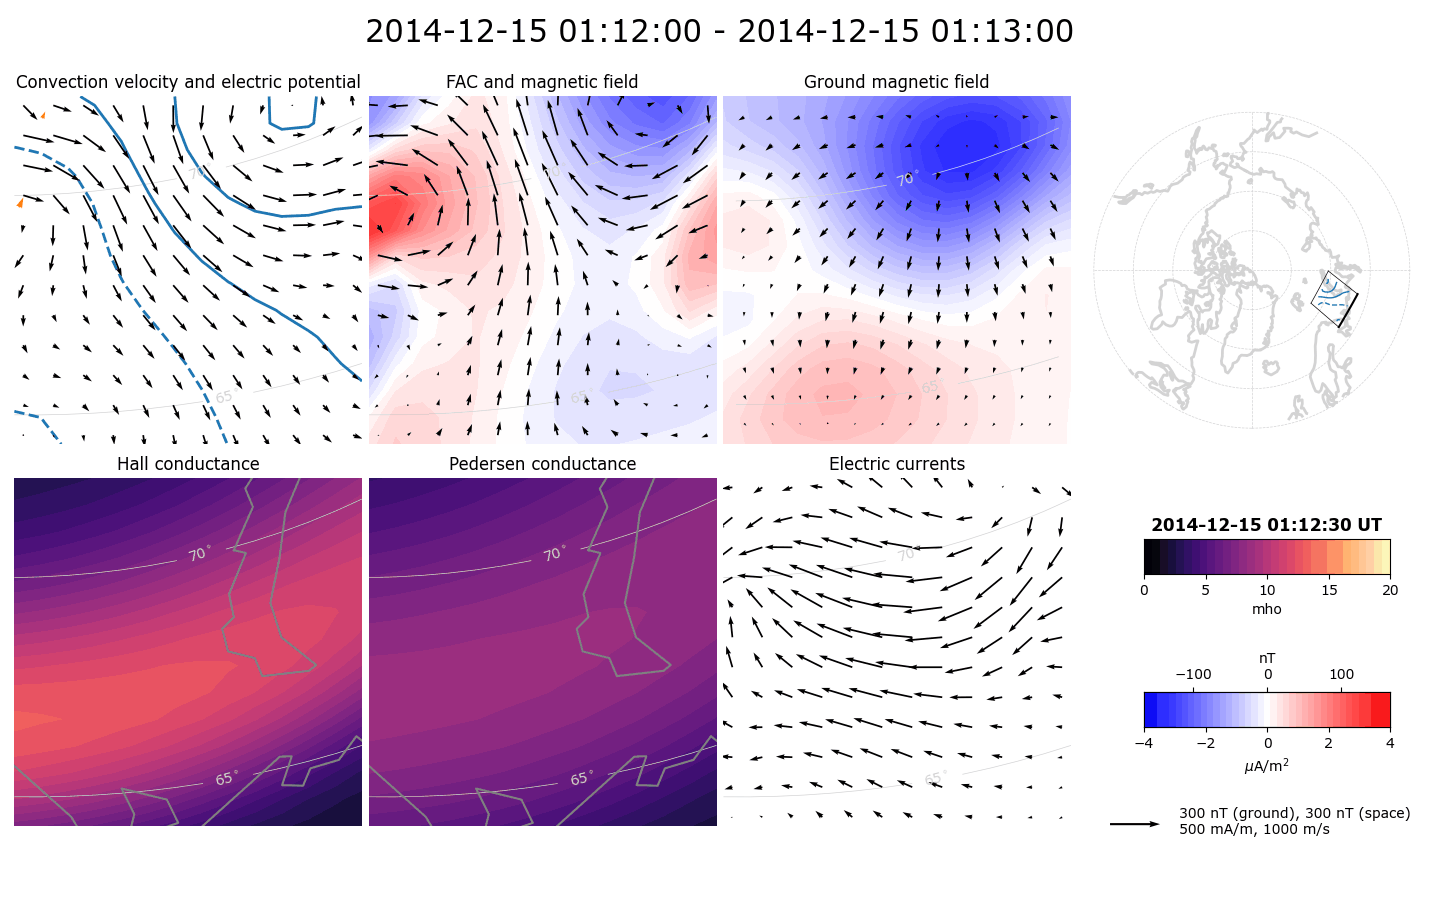

In [12]:
lompe_frames[0].save(
    "lompe.gif",
    save_all=True,
    append_images=lompe_frames[1:],
    duration=750,
    loop=0
)

from IPython.display import Image, display

display(Image(filename='lompe.gif')) #TODO compare with the gif saved in outputs

In [13]:
lompeOSSE_models, gamera_models = run_lompeOSSE(lompe_models)
lompeOSSE_frames, gamera_frames_pil = lompeOSSE_output(lompeOSSE_models, gamera_models, gif_speed)


Running LompeOSSE validation...
Loading Gamera data/snapshot #0
gamera mlat.min():  35.26277357171823 degrees
Low latitude Gamera data (< 50 deg) has been discarded
time offset: 0 hours
2014-12-15 01:12:30

 Initializing synthetic model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset not found
convection dataset found..
helolalii: 40.954139709472656
(55440,)
..Gamera convection data extracted
Skipping empty ground_mag dataset
space_mag_full dataset not found
Skipping empty space_mag_fac dataset
Skipping empty space_mag_fac dataset
fac dataset not found

 Clearing input model...
Adding Gamera datasets

 ...Synthetic model generated
Loading Gamera data/snapshot #0
gamera mlat.min():  35.26277357171823 degrees
Low latitude Gamera data (< 50 deg) has been discarded
time offset: 0 hours
2014-12-15 01:13:30

 Initializing synthetic model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset not found
convection dat

KeyboardInterrupt: 

In [ ]:
lompeOSSE_frames[0].save(
    "lompe.gif",
    save_all=True,
    append_images=lompeOSSE_frames[1:],
    duration=750,
    loop=0
)

from IPython.display import Image, display

display(Image(filename='lompeosse.gif')) #TODO compare with the gif saved in outputs